In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Meta Model Dataset/Training_For_Meta_Model.csv")


d:\miniConda\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:23:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


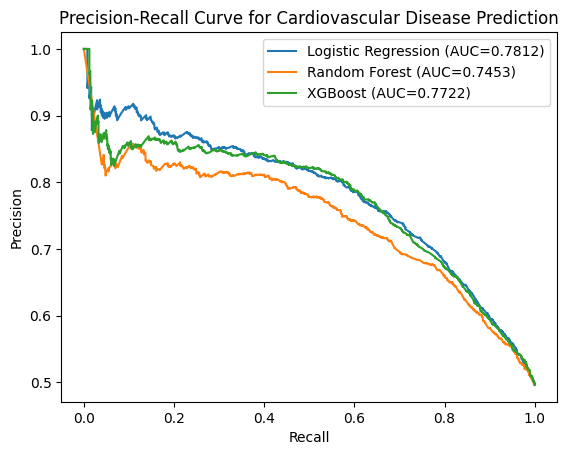

Logistic Regression:
  Precision-Recall AUC = 0.7812
  F1 Score            = 0.7047
  Precision           = 0.7569
  Recall              = 0.6593
  Accuracy            = 0.7261

Random Forest:
  Precision-Recall AUC = 0.7453
  F1 Score            = 0.6806
  Precision           = 0.7221
  Recall              = 0.6435
  Accuracy            = 0.7004

XGBoost:
  Precision-Recall AUC = 0.7722
  F1 Score            = 0.7057
  Precision           = 0.7552
  Recall              = 0.6622
  Accuracy            = 0.7261



In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score



# Define target variable (presence of cardiovascular disease)
y = df["Cardiovascular Disease"]

# Select relevant features
features = ["Age", "Systolic Blood Pressure", "Diastolic Blood Pressure", "Cholesterol Level", "Glucose Level", "Smoking Status", "Alcohol Intake", "Physical Activity"]
X = df[features]

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Train models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

# Evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_scores = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_scores, pos_label=1)
    pr_auc = auc(recall, precision)
    # Default threshold 0.5 for binary prediction
    y_pred = (y_scores >= 0.5).astype(int)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "PR_AUC": pr_auc,
        "F1": f1,
        "Precision": prec,
        "Recall": rec,
        "Accuracy": acc
    }
    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Cardiovascular Disease Prediction")
plt.legend()
plt.show()

# Print model performance
for model, metrics in results.items():
    print(f"{model}:")
    print(f"  Precision-Recall AUC = {metrics['PR_AUC']:.4f}")
    print(f"  F1 Score            = {metrics['F1']:.4f}")
    print(f"  Precision           = {metrics['Precision']:.4f}")
    print(f"  Recall              = {metrics['Recall']:.4f}")
    print(f"  Accuracy            = {metrics['Accuracy']:.4f}")
    print()



In [12]:
#load in Tausif's meta model 
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

model = keras.models.load_model("simple_4_model.h5")    
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy',tf.keras.metrics.AUC()]
)


In [4]:
import lightgbm as lgb

import os


lifestyle_columns_to_drop = ['Cholesterol Level', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Glucose Level', 'id']
health_columns_to_drop = ['Smoking Status', 'Physical Activity', 'Alcohol Intake','id']

X = df.drop(['Cardiovascular Disease'], axis=1)
Y = df['Cardiovascular Disease']


X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2, 
    random_state=42,
    stratify=Y 
)




health_dataset = X_train.drop(columns=health_columns_to_drop)
lifestyle_dataset = X_train.drop(columns=lifestyle_columns_to_drop)





# Load the trained models
#model_A = lgb.Booster(model_file="saved_models_tausif/lightgbm_model_A.txt")
model_B = lgb.Booster(model_file="Models B/lightgbm_model.txt")

#model_A = lgb.load(filename = "saved_models_tausif/lightgbm_model_A.txt")
#model_B = lgb.load(filename = "saved_models_tausif/lightgbm_model_B.txt")

# Predict using the respective datasets
#predictions_A = model_A.predict(lifestyle_dataset)
predictions_B = model_B.predict(health_dataset)


#print(predictions_A)
print(predictions_B)

[0.20400517 0.92270298 0.807062   ... 0.22936528 0.58392303 0.22233091]


In [5]:
model_A = lgb.Booster(model_file="Saved Models A/lightgbm_model.txt")
predictions_A = model_A.predict(lifestyle_dataset)

In [7]:
import numpy as np
meta_features = np.column_stack((predictions_A, predictions_B))
#print(meta_features.shape)

meta_target = Y_train.values  # ensure it's a numpy array

In [13]:
model.evaluate(meta_features, meta_target)




342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 916us/step - accuracy: 0.7183 - auc_2: 0.7841 - loss: 0.5645


[0.5645031332969666, 0.7183408141136169, 0.7840774059295654]

In [10]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

def evaluate_nn_model(model, X_test, Y_actual):
    """
    Evaluate a NN model that outputs probabilities.
    Computes ROC, Precision-Recall curves, and best F1 score automatically.
    """
    
    # Predict probabilities
    Y_prob = model.predict(X_test).flatten()  # flatten in case output is (n,1)
    
    # --- Compute best F1 score by sweeping thresholds ---
    thresholds = np.linspace(0, 1, 101)  # thresholds from 0.0 to 1.0
    f1_scores = [f1_score(Y_actual, (Y_prob >= t).astype(int)) for t in thresholds]
    best_f1 = max(f1_scores)
    best_threshold = thresholds[np.argmax(f1_scores)]
    
    # Binary predictions using the best threshold
    Y_pred_best = (Y_prob >= best_threshold).astype(int)
    
    # --- Metrics ---
    metrics = {
        "F1": best_f1,
        "Best_Threshold": best_threshold,
        "AUC": roc_auc_score(Y_actual, Y_prob)
    }

    # --- ROC curve ---
    fpr, tpr, roc_thresholds = roc_curve(Y_actual, Y_prob)
    metrics["ROC"] = {"fpr": fpr, "tpr": tpr, "thresholds": roc_thresholds}

    # --- Precision-Recall curve ---
    precision, recall, pr_thresholds = precision_recall_curve(Y_actual, Y_prob)
    avg_precision = average_precision_score(Y_actual, Y_prob)
    metrics["Precision_Recall_Curve"] = {"precision": precision, "recall": recall, "thresholds": pr_thresholds}
    metrics["Average_Precision"] = avg_precision

    # --- Plotting ---
    plt.figure(figsize=(12,5))

    # ROC Curve
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f"AUC = {metrics['AUC']:.2f}", color='blue', linewidth=2)
    plt.plot([0,1], [0,1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc='lower right')

    # Precision-Recall Curve
    plt.subplot(1,2,2)
    plt.plot(recall, precision, label=f"Average Precision = {avg_precision:.2f}", color='green', linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

    return metrics


342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step


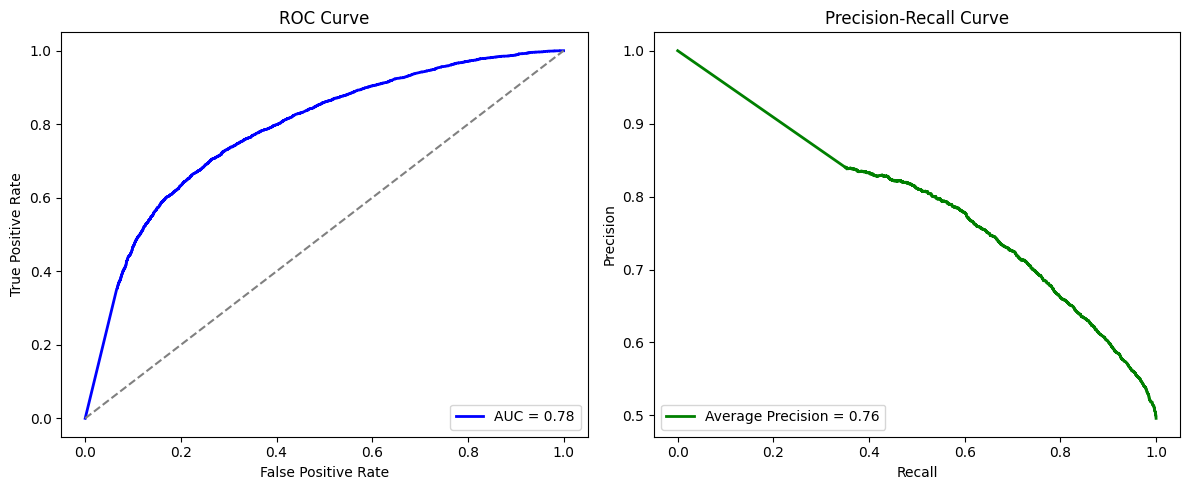

{'F1': 0.7262936080543199,
 'Best_Threshold': np.float64(0.32),
 'AUC': 0.7843085780752559,
 'ROC': {'fpr': array([0.        , 0.0653951 , 0.06557675, ..., 0.99346049, 0.99346049,
         1.        ], shape=(3792,)),
  'tpr': array([0.        , 0.34988922, 0.34988922, ..., 0.99981536, 1.        ,
         1.        ], shape=(3792,)),
  'thresholds': array([       inf, 0.7551898 , 0.75518584, ..., 0.12813385, 0.12805939,
         0.11119846], shape=(3792,), dtype=float32)},
 'Precision_Recall_Curve': {'precision': array([0.49592528, 0.4959707 , 0.49601612, ..., 0.83998227, 0.84035477,
         1.        ], shape=(7416,)),
  'recall': array([1.        , 1.        , 1.        , ..., 0.34988922, 0.34988922,
         0.        ], shape=(7416,)),
  'thresholds': array([0.11119846, 0.11212609, 0.1121795 , ..., 0.75517666, 0.75518584,
         0.7551898 ], shape=(7415,), dtype=float32)},
 'Average_Precision': 0.7614569250975314}

In [14]:
evaluate_nn_model(model, meta_features, meta_target)